Este proyecto pretende detectar si una reclamacion de accidente vehicular es fraude o no

In [17]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('fraud_oracle.csv')

### Diccionario de Datos

| Variable | Tipo | ¿Qué significa? |
| :--- | :--- | :--- |
| Month | Texto | Mes en el que ocurrió el accidente. |
| WeekOfMonth | Número | Semana del mes en la que ocurrió el accidente (1-5). |
| DayOfWeek | Texto | Día de la semana en el que ocurrió el accidente. |
| Make | Texto | Marca del vehículo involucrado. |
| AccidentArea | Texto | Tipo de zona donde ocurrió el accidente (Urbano o Rural). |
| DayOfWeekClaimed | Texto | Día de la semana en el que se realizó la reclamación. |
| MonthClaimed | Texto | Mes en el que se realizó la reclamación. |
| WeekOfMonthClaimed | Número | Semana del mes en la que se realizó la reclamación. |
| Sex | Texto | Género del conductor involucrado. |
| MaritalStatus | Texto | Estado civil del conductor. |
| Age | Número | Edad del conductor involucrado (0 suele indicar datos faltantes). |
| Fault | Texto | Quién fue determinado como culpable (Titular de la póliza o Tercero). |
| PolicyType | Texto | Combinación de categoría de vehículo y tipo de cobertura. |
| VehicleCategory | Texto | Categoría del vehículo (Sedán, Deportivo, Utilitario). |
| VehiclePrice | Texto (Rango) | Rango de precio del vehículo asegurado. |
| FraudFound_P | Binario (0/1) | Indica si se detectó fraude en la reclamación (1: Sí, 0: No). |
| PolicyNumber | Número | Identificador único de la póliza. |
| RepNumber | Número | Identificador del representante que procesó el caso. |
| Deductible | Número | Monto del deducible de la póliza. |
| DriverRating | Número | Calificación del conductor (1 a 4). |
| Days_Policy_Accident | Texto (Rango) | Tiempo transcurrido desde el inicio de la póliza hasta el accidente. |
| Days_Policy_Claim | Texto (Rango) | Tiempo transcurrido desde el inicio de la póliza hasta la reclamación. |
| PastNumberOfClaims | Texto (Rango) | Número de reclamaciones realizadas anteriormente por el asegurado. |
| AgeOfVehicle | Texto (Rango) | Antigüedad del vehículo involucrado. |
| AgeOfPolicyHolder | Texto (Rango) | Rango de edad del titular de la póliza. |
| PoliceReportFiled | Texto (Sí/No) | Indica si se presentó un informe policial del accidente. |
| WitnessPresent | Texto (Sí/No) | Indica si hubo testigos presentes en el accidente. |
| AgentType | Texto | Tipo de agente (Interno o Externo). |
| NumberOfSuppliments | Texto (Rango) | Cantidad de suplementos o anexos añadidos a la reclamación. |
| AddressChange_Claim | Texto | Indica si hubo un cambio de dirección durante el proceso de reclamación. |
| NumberOfCars | Texto (Rango) | Cantidad de vehículos involucrados en el incidente. |
| Year | Número | Año en el que ocurrió el accidente. |
| BasePolicy | Texto | Tipo de cobertura base (Responsabilidad Civil, Colisión, Todo Riesgo). |

In [20]:
df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
df.describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


con df.describe pudimos identificar varias cosas: 
1. que el porcentaje de fraudes encontrados es 5.9% 
2. que edad tiene datos en 0 


In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [24]:
df.isnull().sum().to_string()

'Month                   0\nWeekOfMonth             0\nDayOfWeek               0\nMake                    0\nAccidentArea            0\nDayOfWeekClaimed        0\nMonthClaimed            0\nWeekOfMonthClaimed      0\nSex                     0\nMaritalStatus           0\nAge                     0\nFault                   0\nPolicyType              0\nVehicleCategory         0\nVehiclePrice            0\nFraudFound_P            0\nPolicyNumber            0\nRepNumber               0\nDeductible              0\nDriverRating            0\nDays_Policy_Accident    0\nDays_Policy_Claim       0\nPastNumberOfClaims      0\nAgeOfVehicle            0\nAgeOfPolicyHolder       0\nPoliceReportFiled       0\nWitnessPresent          0\nAgentType               0\nNumberOfSuppliments     0\nAddressChange_Claim     0\nNumberOfCars            0\nYear                    0\nBasePolicy              0'

No hay valores nulos entonces, vamos a mirar duplicados, tipos de datos y cuales columnas si son relevantes y cuales no 

In [26]:
df.duplicated().sum()

np.int64(0)

<Axes: title={'center': 'Unique values per feature'}>

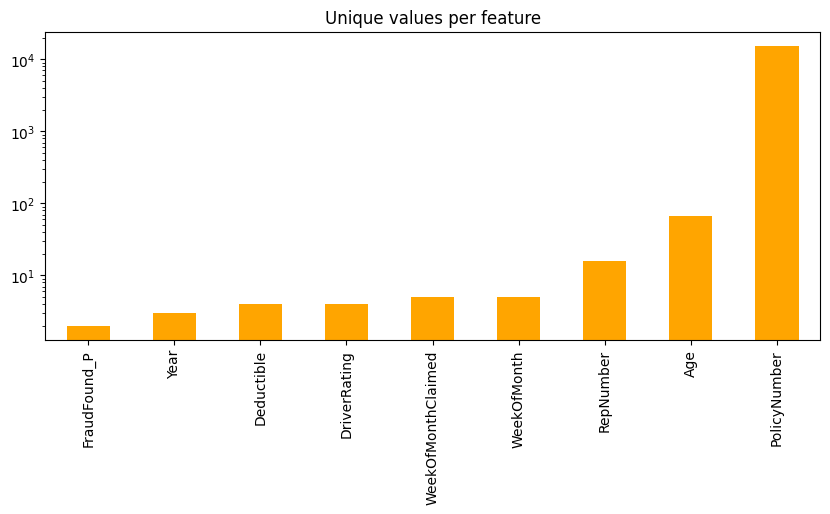

In [31]:
 
unique_values_cat = df.select_dtypes(
  include= "str").nunique().sort_values()

unique_values_con = df.select_dtypes(
  include= "number").nunique().sort_values()

unique_values_con.plot.bar(logy=True, figsize=(10, 4),
                       title="Unique values per feature", color= 'orange')